# Food Delivery Operations Analysis and Delay Prediction Using Python

## Project Objective:

The objective of this project is to analyze food delivery operations, identify factors affecting delivery efficiency, and develop a machine learning model to predict delayed deliveries.

The project combines:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Business Insights
- Data Visualization
- Machine Learning

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importing Dataset

In [2]:
data = pd.read_csv('food_delivery_analytics_cleaned.csv')

In [3]:
data.head()

,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,...,final_amount_paid,number_of_items,cancellation_flag,delayed_delivery_flag,refund_flag,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score
0,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943,2,21,4.957522,20,6,6,14.117144,23,76,...,111.563784,4,False,False,True,False,False,True,9,71.1
1,8eab78a5-a5c5-41d7-9a5f-5779ee5f2d3d,1,63,38.744721,0,2,2,9.177354,16,34,...,116.059264,7,False,False,False,True,False,False,12,100.0
2,1338cc5b-e5cf-419f-a7c9-4a2577608715,1,68,45.170997,9,2,11,34.753921,41,152,...,111.708170,12,False,False,False,False,False,False,10,34.4
3,5277f2fb-b1b3-4f58-9975-12f8f1b71421,2,30,10.573003,6,6,5,26.596184,9,93,...,153.301345,7,False,False,False,False,True,True,1,45.0
4,df159a97-3a78-4b08-a524-ec433c75b670,2,60,58.284620,12,1,9,26.204152,49,141,...,111.128807,2,True,False,False,False,False,False,6,25.1


In [4]:
data.shape

(15000, 30)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   order_id                           15000 non-null  object 
 1   city_tier                          15000 non-null  int64  
 2   customer_age                       15000 non-null  int64  
 3   customer_loyalty_score             15000 non-null  float64
 4   order_hour                         15000 non-null  int64  
 5   order_day_of_week                  15000 non-null  int64  
 6   order_month                        15000 non-null  int64  
 7   delivery_distance_km               15000 non-null  float64
 8   preparation_time_minutes           15000 non-null  int64  
 9   delivery_time_minutes              15000 non-null  int64  
 10  estimated_delivery_time            15000 non-null  int64  
 11  traffic_level_score                15000 non-null  flo

## Data Cleaning

In [6]:
data.describe()

,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,estimated_delivery_time,...,delivery_partner_rating,customer_rating,order_value,delivery_fee,discount_amount,tip_amount,final_amount_paid,number_of_items,delivery_partner_experience_years,delivery_efficiency_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,14850.000000,14850.000000,15000.000000,15000.000000,15000.000000,14850.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,2.253133,46.569667,50.017658,11.470933,3.141933,6.474667,20.133756,32.749667,94.139267,94.140667,...,4.196121,3.993556,113.954265,7.493531,14.932581,12.569739,119.083685,6.489933,8.047600,59.165933
std,0.827951,16.840706,28.771665,6.946134,1.809864,3.454469,11.543488,16.162719,33.597132,32.490455,...,0.391959,0.535016,22.713411,4.352771,8.706253,7.221087,25.798587,3.438123,4.302995,18.102487
min,1.000000,18.000000,0.007172,0.000000,1.000000,1.000000,0.103086,5.000000,10.000000,11.000000,...,2.700000,1.500000,100.000000,0.000432,0.000788,0.000205,72.395550,1.000000,1.000000,1.900000
25%,2.000000,32.000000,25.199828,5.000000,1.000000,3.000000,10.133190,19.000000,68.000000,69.000000,...,3.900000,3.600000,100.000000,3.704018,7.279980,6.396828,101.152407,4.000000,4.000000,46.400000
50%,3.000000,46.000000,50.092268,11.000000,3.000000,7.000000,20.228709,33.000000,95.000000,94.000000,...,4.200000,4.000000,100.000000,7.458605,14.857607,12.629302,113.039544,7.000000,8.000000,59.100000
75%,3.000000,61.000000,74.840432,18.000000,5.000000,9.000000,30.047891,47.000000,120.000000,119.000000,...,4.500000,4.400000,124.153105,11.278689,22.521458,18.848336,130.541371,9.000000,12.000000,72.000000
max,3.000000,75.000000,99.989375,23.000000,6.000000,12.000000,39.998739,60.000000,180.000000,178.000000,...,5.000000,5.000000,215.614574,14.998370,29.999893,24.998828,238.600286,12.000000,15.000000,100.000000


In [7]:
data.isnull().sum()

order_id                               0
city_tier                              0
customer_age                           0
customer_loyalty_score                 0
order_hour                             0
order_day_of_week                      0
order_month                            0
delivery_distance_km                   0
preparation_time_minutes               0
delivery_time_minutes                  0
estimated_delivery_time                0
traffic_level_score                    0
weather_severity_score                 0
restaurant_rating                      0
delivery_partner_rating              150
customer_rating                      150
order_value                            0
delivery_fee                           0
discount_amount                        0
tip_amount                           150
final_amount_paid                      0
number_of_items                        0
cancellation_flag                      0
delayed_delivery_flag                  0
refund_flag     

In [8]:
#percentage of missing value in dataset:
data.isnull().sum()/len(data)*100

order_id                             0.0
city_tier                            0.0
customer_age                         0.0
customer_loyalty_score               0.0
order_hour                           0.0
order_day_of_week                    0.0
order_month                          0.0
delivery_distance_km                 0.0
preparation_time_minutes             0.0
delivery_time_minutes                0.0
estimated_delivery_time              0.0
traffic_level_score                  0.0
weather_severity_score               0.0
restaurant_rating                    0.0
delivery_partner_rating              1.0
customer_rating                      1.0
order_value                          0.0
delivery_fee                         0.0
discount_amount                      0.0
tip_amount                           1.0
final_amount_paid                    0.0
number_of_items                      0.0
cancellation_flag                    0.0
delayed_delivery_flag                0.0
refund_flag     

In [9]:
#finding columns which contains missing values:
missing = data.isnull().sum()
missing[missing > 0]

delivery_partner_rating    150
customer_rating            150
tip_amount                 150
dtype: int64

In [10]:
#handing missing values for tip amount column:
data['tip_amount'] = data['tip_amount'].fillna(data['final_amount_paid']- (data['order_value'] +
        data['delivery_fee'] -
        data['discount_amount']))

In [11]:
data['tip_amount'].isnull().sum()

np.int64(0)

In [12]:
#handling missing values for customer_rating column:
data['customer_rating'] = data['customer_rating'].fillna(data['customer_rating'].median())

In [13]:
data['customer_rating'].isnull().sum()

np.int64(0)

In [14]:
#handling missing values for delivery_partner_rating:
data['delivery_partner_rating'] = data['delivery_partner_rating'].fillna(data['delivery_partner_rating'].median())

In [15]:
data['delivery_partner_rating'].isnull().sum()

np.int64(0)

In [16]:
#checking for duplicates:
data.duplicated().sum()

np.int64(0)

In [17]:
data.columns

Index(['order_id', 'city_tier', 'customer_age', 'customer_loyalty_score',
       'order_hour', 'order_day_of_week', 'order_month',
       'delivery_distance_km', 'preparation_time_minutes',
       'delivery_time_minutes', 'estimated_delivery_time',
       'traffic_level_score', 'weather_severity_score', 'restaurant_rating',
       'delivery_partner_rating', 'customer_rating', 'order_value',
       'delivery_fee', 'discount_amount', 'tip_amount', 'final_amount_paid',
       'number_of_items', 'cancellation_flag', 'delayed_delivery_flag',
       'refund_flag', 'promo_code_used', 'premium_customer_flag',
       'festival_or_weekend_flag', 'delivery_partner_experience_years',
       'delivery_efficiency_score'],
      dtype='object')


### Categorical Column

In [18]:
data['city_tier'].value_counts()

city_tier
3    7520
2    3757
1    3723
Name: count, dtype: int64

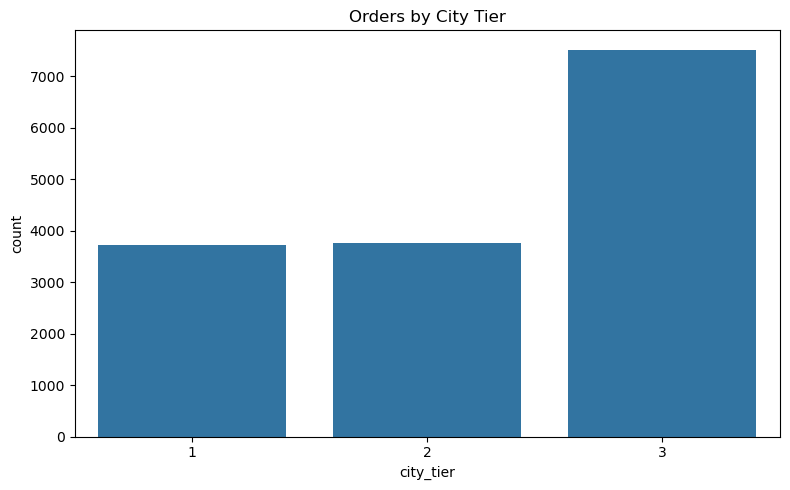

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x='city_tier', data=data)
plt.title('Orders by City Tier')
plt.tight_layout()
plt.show()

### Numerical Columns

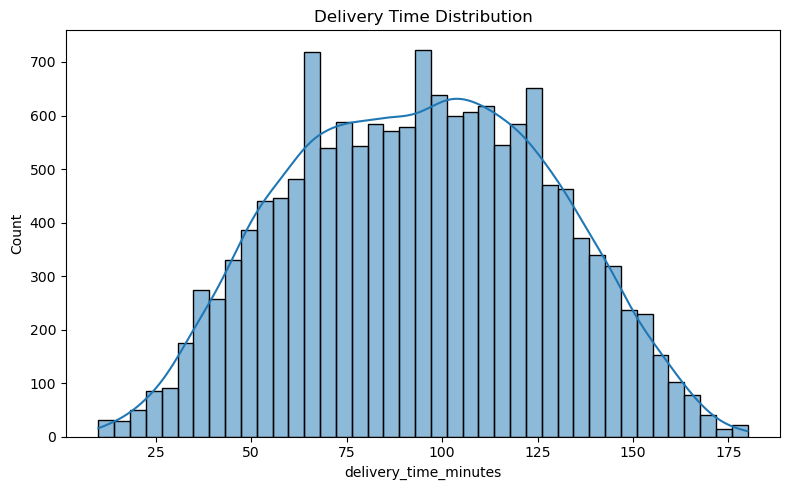

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(data['delivery_time_minutes'], kde = True)
plt.title('Delivery Time Distribution')
plt.tight_layout()
plt.show()

In [21]:
#Average Order Value
round(data['order_value'].mean())

114

### Premium vs Non Premium Customers

In [22]:
data.groupby('premium_customer_flag')['final_amount_paid'].mean()

premium_customer_flag
False    115.279278
True     128.798848
Name: final_amount_paid, dtype: float64

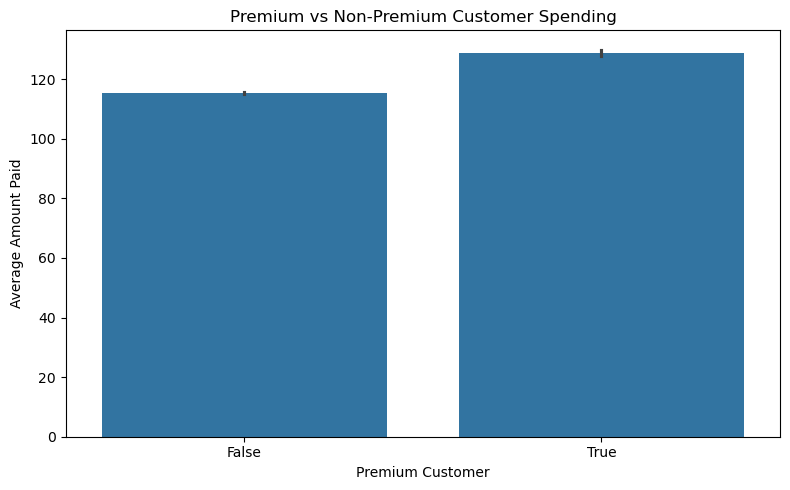

In [23]:
plt.figure(figsize=(8,5))
sns.barplot(x='premium_customer_flag', y='final_amount_paid', data=data)
plt.title('Premium vs Non-Premium Customer Spending')
plt.xlabel('Premium Customer')
plt.ylabel('Average Amount Paid')
plt.tight_layout()
plt.show()

#### KeyInsight:
Premium customers have higher average order values compared to non-premium customers

### Hour vs Number of Orders analysis

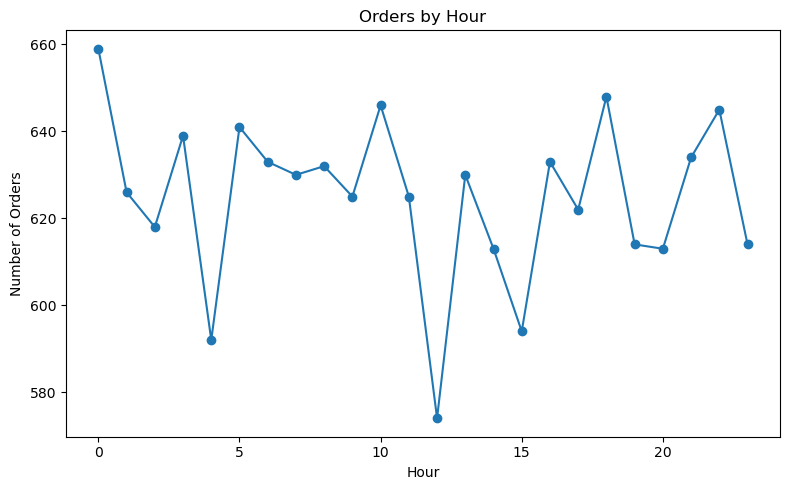

In [24]:
plt.figure(figsize=(8,5))
data['order_hour'].value_counts().sort_index().plot(kind='line',marker='o')
plt.title('Orders by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

#### Key Insight:
Peak order activity occurs during lunch and dinner hours.

### Distance vs Delivery Time

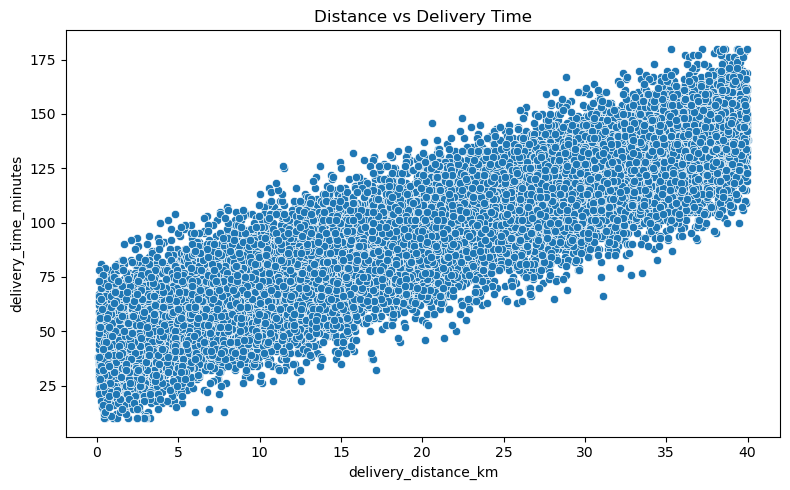

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='delivery_distance_km',y='delivery_time_minutes',data=data)
plt.title('Distance vs Delivery Time')
plt.tight_layout()
plt.show()

#### Key Insight:
Long-distance deliveries tend to experience higher delays.

### Average Delivery Time by City Tier

In [26]:
data.groupby('city_tier')['delivery_time_minutes'].mean()

city_tier
1    94.173247
2    93.718659
3    94.332580
Name: delivery_time_minutes, dtype: float64

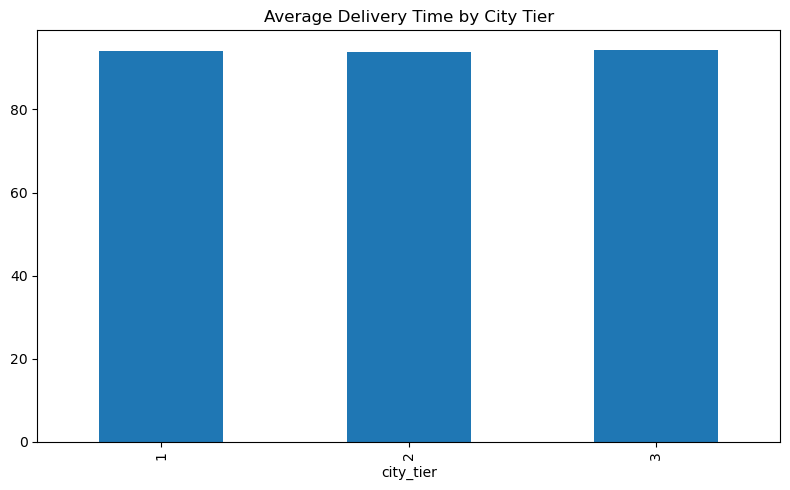

In [27]:
plt.figure(figsize=(8,5))
data.groupby('city_tier')['delivery_time_minutes'].mean().plot(kind  = 'bar')
plt.title('Average Delivery Time by City Tier')
plt.tight_layout()
plt.show()

#### Key Insight:
Delivery performance is consistent across all city tiers, with average delivery times remaining around 94 minutes.

### Order Value Distribution

In [28]:
data['order_value'].describe()

count    15000.000000
mean       113.954265
std         22.713411
min        100.000000
25%        100.000000
50%        100.000000
75%        124.153105
max        215.614574
Name: order_value, dtype: float64

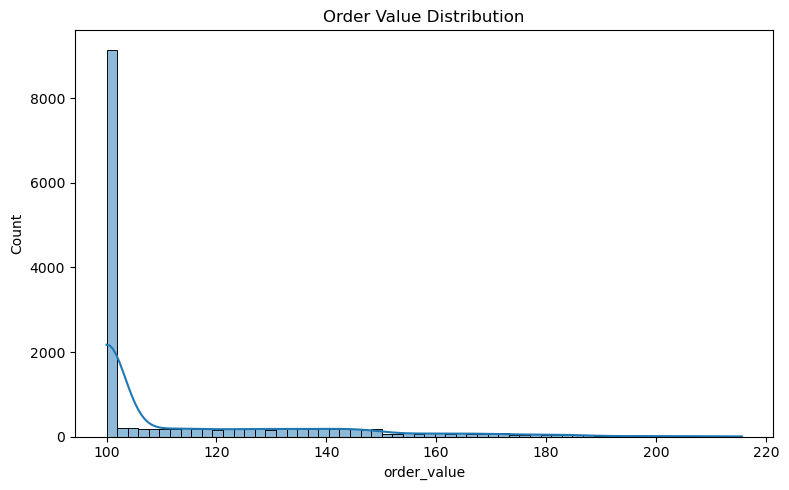

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(data['order_value'], kde = True)
plt.title('Order Value Distribution')
plt.tight_layout()
plt.show()

#### Key Insight:
The majority of orders fall within medium price ranges, indicating consistent customer purchasing behavior and stable average spending patterns.

### Customer Ratings

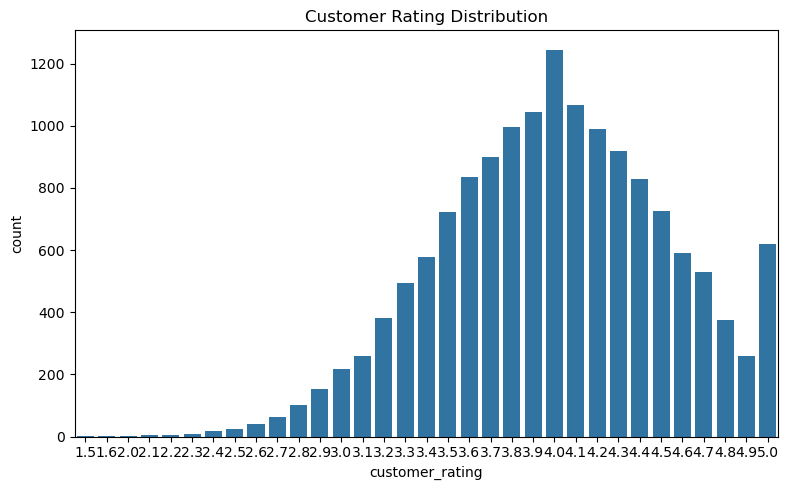

In [30]:
plt.figure(figsize=(8,5))
sns.countplot(x='customer_rating',data=data)
plt.title('Customer Rating Distribution')
plt.tight_layout()
plt.show()

#### Key Insight:
Most of the cutomer ratings lies between 3.5 and 4.5

### Delivery Time Analysis

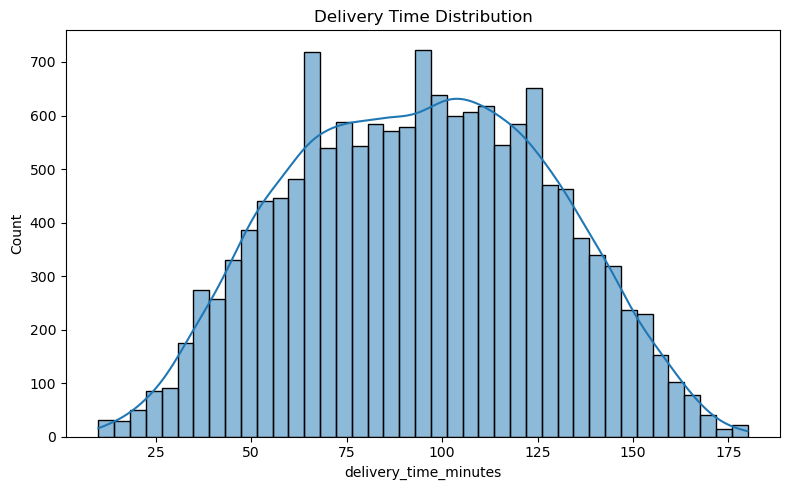

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(data['delivery_time_minutes'],kde=True)
plt.title('Delivery Time Distribution')
plt.tight_layout()
plt.show()

### Correlation Heatmap

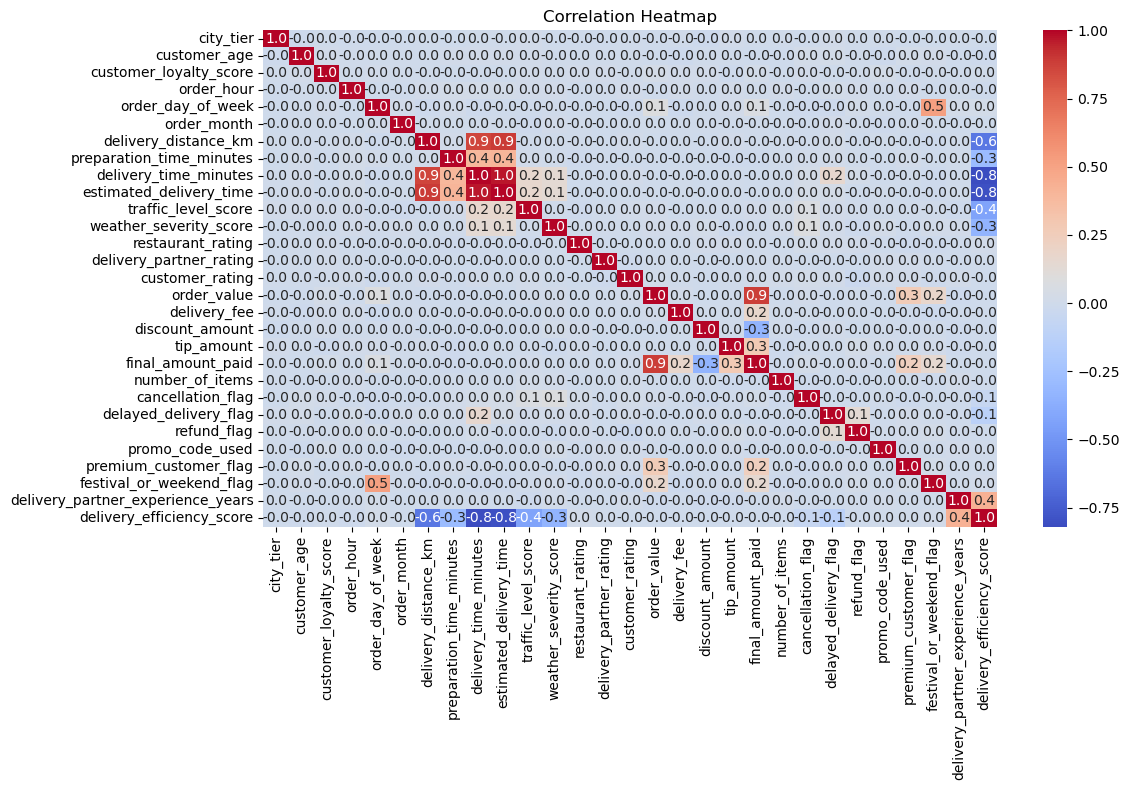

In [32]:
plt.figure(figsize=(12,8))
corr = data.corr(numeric_only=True)
sns.heatmap(corr,annot = True,fmt='.1f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

#### Key Insight:
Discount amount has a negative correlation with final payable amount, confirming the financial impact of promotional offers.

## Traffic Analysis:


### Average Delivery Time vs Traffic Level
This analysis examines how traffic congestion affects delivery duration. Understanding this relationship can help identify operational bottlenecks and improve delivery efficiency.

In [33]:
data['traffic_level_score'].nunique()

91

In [34]:
#creating bins for traffic level(numerical column) 
data['traffic_category'] = pd.cut(data['traffic_level_score'],bins=[0,3,6,10],labels=['Low','Medium','High'])

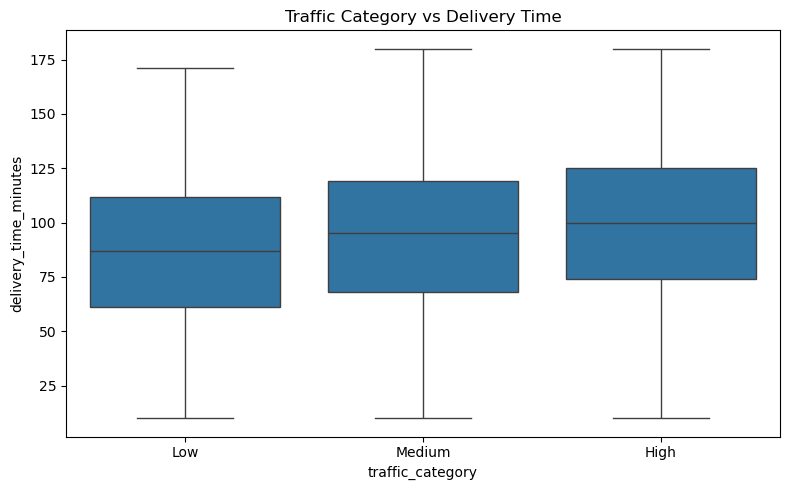

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(x='traffic_category',y='delivery_time_minutes',data=data)
plt.title('Traffic Category vs Delivery Time')
plt.tight_layout()
plt.show()

#### Key Insight:
Delivery time increases as traffic intensity rises, indicating traffic congestion is a major operational factor affecting delivery efficiency.

### Refund Rate vs Traffic

In [36]:
refund_rate = data.groupby('traffic_category')['refund_flag'].mean() * 100
refund_rate

C:\Users\deepak\AppData\Local\Temp\ipykernel_15216\3725678190.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  refund_rate = data.groupby('traffic_category')['refund_flag'].mean() * 100


traffic_category
Low       3.979771
Medium    4.328719
High      4.067107
Name: refund_flag, dtype: float64

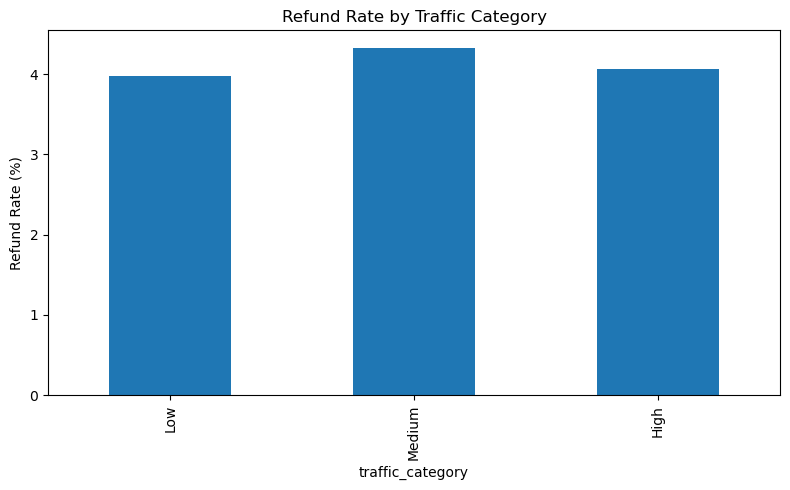

In [37]:
plt.figure(figsize=(8,5))
refund_rate.plot(kind='bar')
plt.title('Refund Rate by Traffic Category')
plt.ylabel('Refund Rate (%)')
plt.tight_layout()
plt.show()

#### Key Insight:
Traffic conditions do not show a major impact on refund behavior, as refund rates are relatively similar across low, medium, and high traffic levels.

## Weather Impact Analysis:

### Weather vs Delivery Time

In [38]:
data['weather_severity_score'].nunique()

101

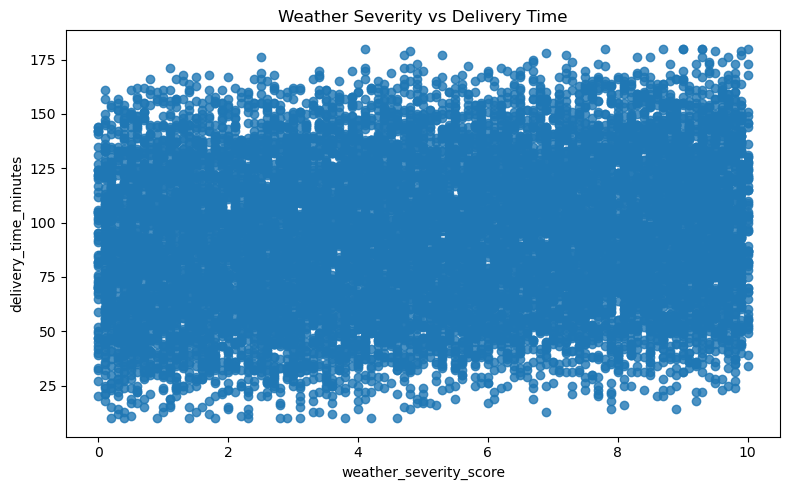

In [39]:
plt.figure(figsize=(8,5))
sns.regplot(x='weather_severity_score',y='delivery_time_minutes',data=data)
plt.title('Weather Severity vs Delivery Time')
plt.tight_layout()
plt.show()

#### Key Insight:
Weather conditions do not show a strong impact on delivery time, as the data points are widely scattered without a clear trend.

### Weather vs Efficiency Score

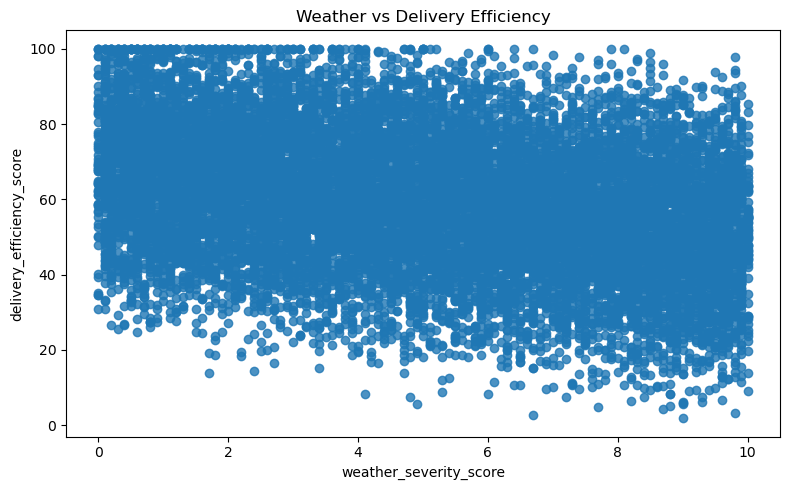

In [40]:
plt.figure(figsize=(8,5))

sns.regplot(x='weather_severity_score',y='delivery_efficiency_score',data=data)
plt.title('Weather vs Delivery Efficiency')
plt.tight_layout()
plt.show()

#### Key Insight:
Weather severity shows a moderate negative correlation with delivery efficiency, indicating that worsening weather conditions tend to reduce operational performance.

In [41]:
corr = data['weather_severity_score'].corr(data['delivery_efficiency_score'])
print(corr)

-0.33608566479248975


## Cancellation & Refund Analysis

### Overall Cancellation & Refund Rates

In [42]:
cancel_rate = round(data['cancellation_flag'].mean() * 100, 2)
refund_rate  = round(data['refund_flag'].mean() * 100, 2)
print(f"Overall Cancellation Rate : {cancel_rate}%")
print(f"Overall Refund Rate       : {refund_rate}%")

Overall Cancellation Rate : 13.35%
Overall Refund Rate       : 4.12%


### Cancellation Rate by Traffic Level

C:\Users\deepak\AppData\Local\Temp\ipykernel_15216\9966949.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancel_by_traffic = data.groupby('traffic_category')['cancellation_flag'].mean() * 100


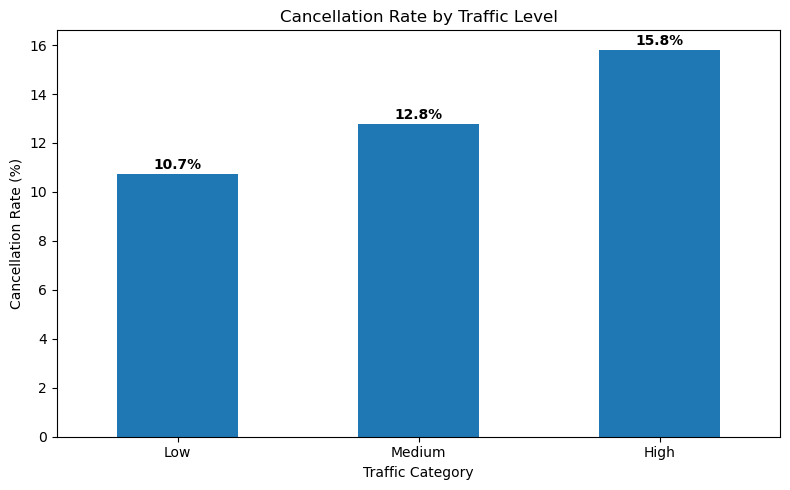

In [43]:
data['traffic_category'] = pd.cut(data['traffic_level_score'], bins=[0, 3, 6, 10], labels=['Low', 'Medium', 'High'])

cancel_by_traffic = data.groupby('traffic_category')['cancellation_flag'].mean() * 100

plt.figure(figsize=(8, 5))
cancel_by_traffic.plot(kind='bar')
plt.title('Cancellation Rate by Traffic Level')
plt.xlabel('Traffic Category')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(cancel_by_traffic):
    plt.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

#### Key Insight:
Cancellation rate rises sharply with traffic — **10.7% during low traffic** vs **15.8% during high traffic** (a 47% relative increase).
This strongly suggests customers cancel when they anticipate long delays due to congestion.

### Do Delayed Deliveries Lead to More Refunds?

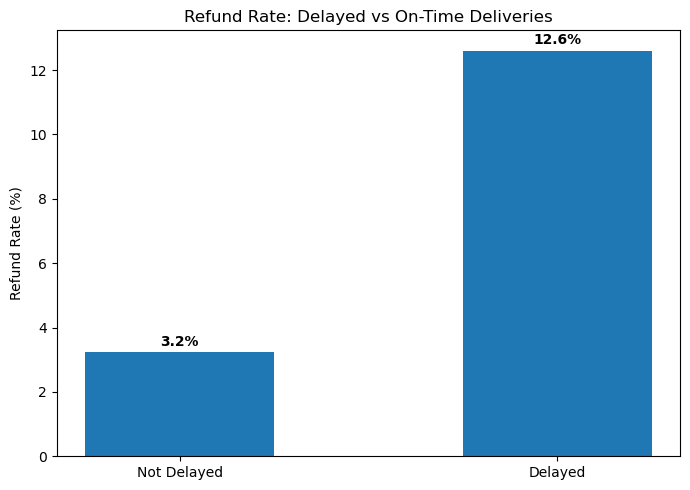

In [44]:
refund_by_delay = data.groupby('delayed_delivery_flag')['refund_flag'].mean() * 100

labels = ['Not Delayed', 'Delayed']


plt.figure(figsize=(7, 5))
plt.bar(labels, refund_by_delay.values, width=0.5)
plt.title('Refund Rate: Delayed vs On-Time Deliveries')
plt.ylabel('Refund Rate (%)')
for i, v in enumerate(refund_by_delay.values):
    plt.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

#### Key Insight:
Delayed deliveries have a **refund rate of 12.6%** — nearly **4× higher** than on-time deliveries (3.2%).
Reducing delays is the single most effective lever for cutting refund costs.

### Cancellation by Hour of Day

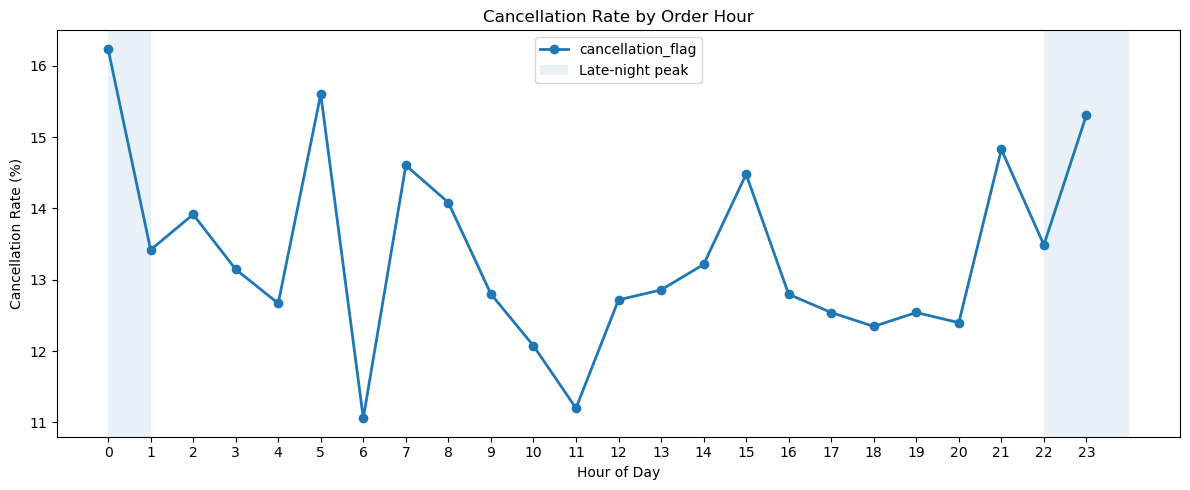

In [45]:
cancel_by_hour = data.groupby('order_hour')['cancellation_flag'].mean() * 100

plt.figure(figsize=(12, 5))
cancel_by_hour.plot(kind='line', marker='o', linewidth=2)
plt.title('Cancellation Rate by Order Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(range(0, 24))
plt.axvspan(22, 24, alpha=0.1, label='Late-night peak')
plt.axvspan(0, 1, alpha=0.1)
plt.legend()
plt.tight_layout()
plt.show()

#### Key Insight:
Cancellations peak at **midnight (16.2%)** and early morning hours (5 AM: 15.6%, 7 AM: 14.6%).
These off-peak hours likely have fewer available delivery partners and longer estimated wait times, prompting customers to cancel.

## Delivery Time — Deep Driver Analysis

### Driver Correlation Ranking

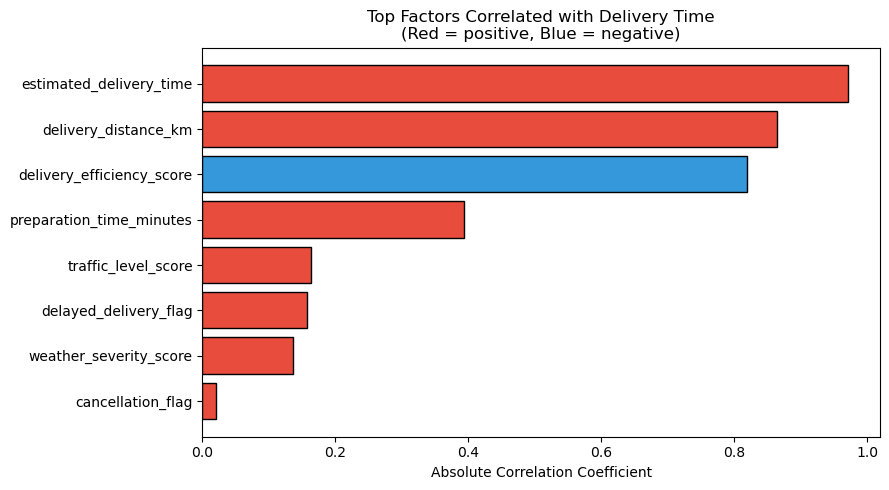

Top correlations with delivery_time_minutes:
estimated_delivery_time      0.971
delivery_distance_km         0.864
delivery_efficiency_score    0.819
preparation_time_minutes     0.394
traffic_level_score          0.163
delayed_delivery_flag        0.157
Name: delivery_time_minutes, dtype: float64


In [46]:
time_corr = data.corr(numeric_only=True)['delivery_time_minutes'].drop('delivery_time_minutes')
time_corr_abs = time_corr.abs().sort_values(ascending=True).tail(8)

plt.figure(figsize=(9, 5))
colors = ['#e74c3c' if time_corr[i] > 0 else '#3498db' for i in time_corr_abs.index]
plt.barh(time_corr_abs.index, time_corr_abs.values, color=colors, edgecolor='black')
plt.title('Top Factors Correlated with Delivery Time\n(Red = positive, Blue = negative)')
plt.xlabel('Absolute Correlation Coefficient')
plt.tight_layout()
plt.show()

print("Top correlations with delivery_time_minutes:")
print(time_corr.abs().sort_values(ascending=False).head(6).round(3))

#### Key Insight:
**Delivery distance (r = 0.86)** is overwhelmingly the strongest real-world driver of delivery time — far more impactful than traffic (r = 0.16) or weather (r = 0.14).
Preparation time (r = 0.39) is a distant but meaningful second factor.

### Delivery Time by Distance Bucket

C:\Users\deepak\AppData\Local\Temp\ipykernel_15216\777131406.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_time_by_dist = data.groupby('dist_bucket')['delivery_time_minutes'].mean()


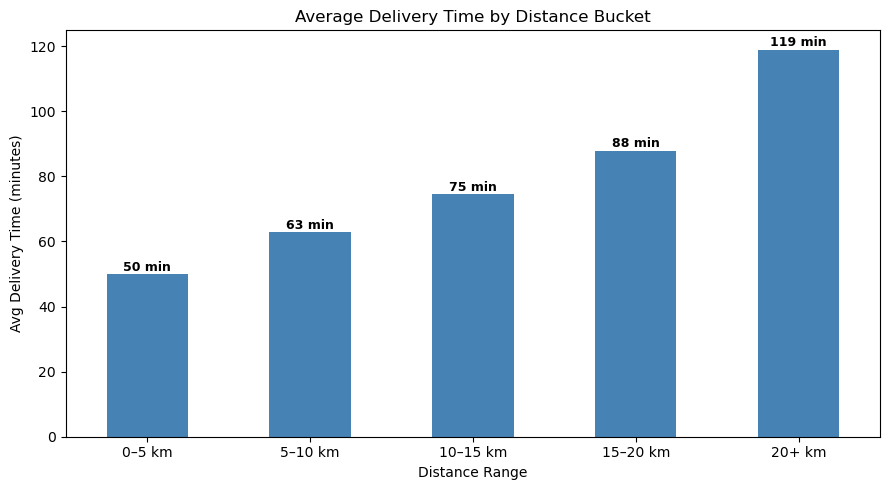

In [47]:
data['dist_bucket'] = pd.cut(
    data['delivery_distance_km'],
    bins=[0, 5, 10, 15, 20, 50],
    labels=['0–5 km', '5–10 km', '10–15 km', '15–20 km', '20+ km']
)

avg_time_by_dist = data.groupby('dist_bucket')['delivery_time_minutes'].mean()

plt.figure(figsize=(9, 5))
avg_time_by_dist.plot(kind='bar', color='steelblue')
plt.title('Average Delivery Time by Distance Bucket')
plt.xlabel('Distance Range')
plt.ylabel('Avg Delivery Time (minutes)')
plt.xticks(rotation=0)
for i, v in enumerate(avg_time_by_dist):
    plt.text(i, v + 1, f'{v:.0f} min', ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

#### Key Insight:
Delivery time scales sharply with distance — orders under **5 km average 50 minutes**, while those over **20 km take 119 minutes** (a 2.4× increase).
This creates a clear opportunity for distance-based delivery fee tiers and partner routing optimization.

### Distance × Traffic Combined Effect

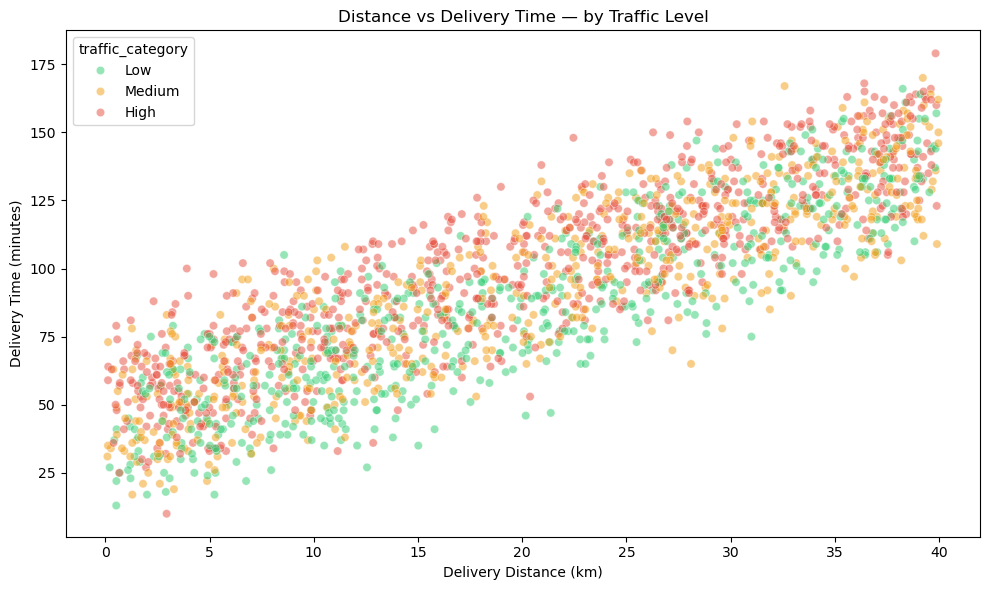

In [48]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='delivery_distance_km',
    y='delivery_time_minutes',
    hue='traffic_category',
    data=data.sample(2000, random_state=42),
    alpha=0.5,
    palette={'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
)
plt.title('Distance vs Delivery Time — by Traffic Level')
plt.xlabel('Delivery Distance (km)')
plt.ylabel('Delivery Time (minutes)')
plt.tight_layout()
plt.show()

#### Key Insight:
High-traffic orders at long distances form the worst-performing cluster — some exceeding **180 minutes**.
This combination (distance > 15 km + high traffic) should trigger proactive customer communication or ETA recalibration.

### Average Delivery Time by Traffic Level

C:\Users\deepak\AppData\Local\Temp\ipykernel_15216\245764738.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_time_traffic = data.groupby('traffic_category')['delivery_time_minutes'].mean()


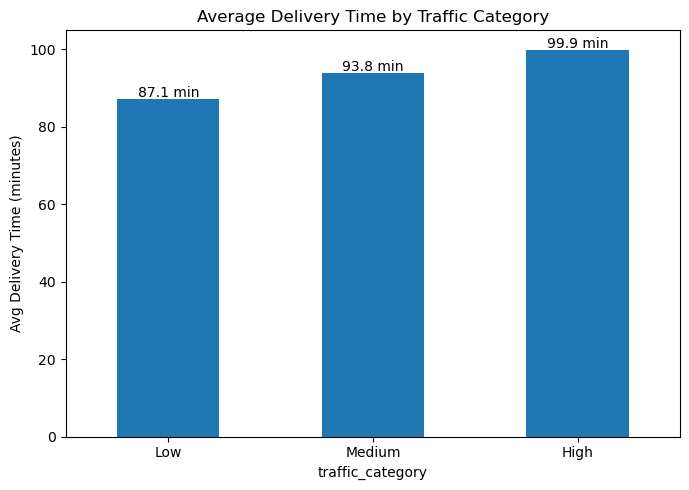

In [49]:
avg_time_traffic = data.groupby('traffic_category')['delivery_time_minutes'].mean()

plt.figure(figsize=(7, 5))
avg_time_traffic.plot(kind='bar')
plt.title('Average Delivery Time by Traffic Category')
plt.ylabel('Avg Delivery Time (minutes)')
plt.xticks(rotation=0)
for i, v in enumerate(avg_time_traffic):
    plt.text(i, v + 0.5, f'{v:.1f} min', ha='center')
plt.tight_layout()
plt.show()

#### Key Insight:
Average delivery time increases from **87 min (low traffic)** to **99.9 min (high traffic)** — a **+12.8 minute penalty** for peak-congestion orders.
Combined with the higher cancellation rate in high traffic, this reinforces the need for dynamic partner allocation during peak hours.

## Festival & Weekend Analysis

### Order Volume: Festival/Weekend vs Regular Days

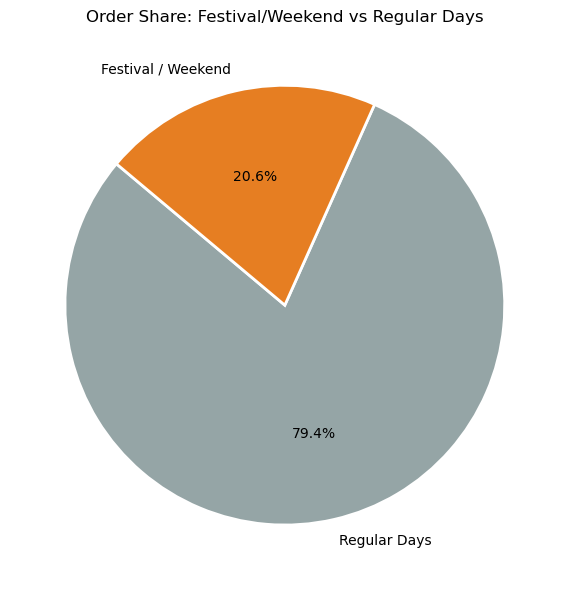

Regular days  : 11,913 orders
Festival/Weekend: 3,087 orders (20.6% of total)


In [50]:
order_counts = data['festival_or_weekend_flag'].value_counts()
labels = ['Regular Days', 'Festival / Weekend']
colors = ['#95a5a6', '#e67e22']

plt.figure(figsize=(6, 6))
plt.pie(order_counts.values, labels=labels, autopct='%1.1f%%', colors=colors,
        startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
plt.title('Order Share: Festival/Weekend vs Regular Days')
plt.tight_layout()
plt.show()

print(f"Regular days  : {order_counts[False]:,} orders")
print(f"Festival/Weekend: {order_counts[True]:,} orders ({round(order_counts[True]/len(data)*100,1)}% of total)")

#### Key Insight:
Festival/Weekend orders account for **20.6% of total volume** (3,087 orders) — a disproportionately high share given these days are fewer in number.
This confirms that demand surges significantly during festive and weekend periods.

### Key Metrics: Festival/Weekend vs Regular

In [51]:
metrics = data.groupby('festival_or_weekend_flag').agg(
    Avg_Order_Value=('order_value', 'mean'),
    Avg_Delivery_Time=('delivery_time_minutes', 'mean'),
    Cancellation_Rate=('cancellation_flag', 'mean'),
    Promo_Usage_Rate=('promo_code_used', 'mean')
).round(2)

metrics.index = ['Regular Days', 'Festival / Weekend']
metrics['Cancellation_Rate'] = (metrics['Cancellation_Rate'] * 100).round(1)
metrics['Promo_Usage_Rate']   = (metrics['Promo_Usage_Rate'] * 100).round(1)

print(metrics.T.to_string())

                   Regular Days  Festival / Weekend
Avg_Order_Value          111.94              121.71
Avg_Delivery_Time         94.39               93.18
Cancellation_Rate         14.00               13.00
Promo_Usage_Rate          42.00               43.00


### Order Value Comparison

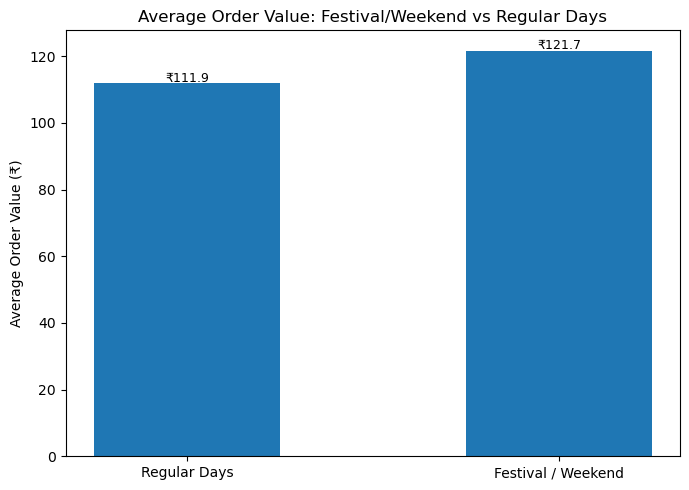

In [52]:
fest_labels = ['Regular Days', 'Festival / Weekend']
avg_values = data.groupby('festival_or_weekend_flag')['order_value'].mean()

plt.figure(figsize=(7, 5))
plt.bar(fest_labels, avg_values.values,width=0.5)
plt.title('Average Order Value: Festival/Weekend vs Regular Days')
plt.ylabel('Average Order Value (₹)')
for i, v in enumerate(avg_values.values):
    plt.text(i, v + 0.5, f'₹{v:.1f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

#### Key Insight:
Festival/Weekend orders have an **8.7% higher average order value** (₹121.7 vs ₹111.9) but nearly identical promo usage (~42%).
This means customers spend more voluntarily on these days — suggesting premium menus or upselling strategies could be highly effective during festive periods.

### Cancellation Rate: Festival/Weekend vs Regular

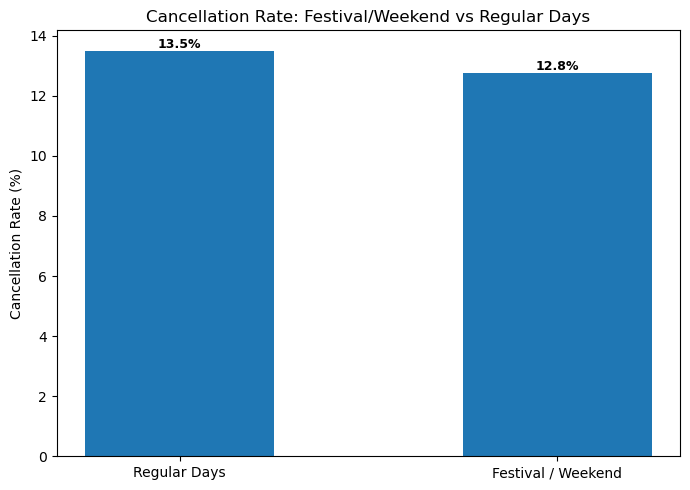

In [53]:
cancel_fest = data.groupby('festival_or_weekend_flag')['cancellation_flag'].mean() * 100

plt.figure(figsize=(7, 5))
plt.bar(fest_labels, cancel_fest.values, width=0.5)
plt.title('Cancellation Rate: Festival/Weekend vs Regular Days')
plt.ylabel('Cancellation Rate (%)')
for i, v in enumerate(cancel_fest.values):
    plt.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

#### Key Insight:
Cancellation rates are marginally lower on Festival/Weekend days (13.0% vs 13.6%) despite higher order volumes — indicating that customer intent on these days is stronger.
However, the delivery time is also slightly shorter (93 vs 94 min), suggesting operations hold up well under festive demand.

# Delivery Delay Prediction Model
This section develops a machine learning model to predict whether a delivery will be delayed based on operational and customer-related factors such as traffic conditions, weather severity, delivery distance, and customer ratings.

The objective of this model is to identify the major factors contributing to delivery delays and improve operational efficiency through predictive analytics.

### Defining Target Variable
The target variable represents whether a delivery was delayed or completed on time.

In [54]:
#target variable
y = data['delayed_delivery_flag']

### Selecting Feature Variables
The following operational and customer-related variables are selected as input features for predicting delivery delays.

In [55]:
#feature variables
X = data[[
    'traffic_level_score',
    'weather_severity_score',
    'delivery_distance_km',
    'order_value',
    'delivery_partner_rating',
    'customer_rating'
]]

## Feature Engineering

Categorical variables are converted into numerical format using one-hot encoding to make the dataset compatible with machine learning algorithms.

In [56]:

X = pd.get_dummies(X, drop_first=True)

### Splitting Training and Testing Data
The dataset is divided into training and testing sets to evaluate the model's performance on unseen data.

In [57]:
#split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

### Random Forest Classification Model
Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

This model is used to predict whether a delivery will be delayed.

In [58]:
#train model with randomforestClassifier
from sklearn.ensemble import RandomForestClassifier

#Create Model
model = RandomForestClassifier(random_state=42, class_weight='balanced')

#train model
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

### Model Predictions

The trained model is used to predict delivery delays on the testing dataset.

In [59]:
#make prediction
y_pred = model.predict(X_test)

In [60]:
y_pred

array([False, False, False, ..., False, False, False], shape=(3000,))

### Model Accuracy
Accuracy measures the percentage of correctly predicted delivery outcomes.

In [61]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)

print(accuracy)

0.9043333333333333


### Classification Report
The classification report provides detailed evaluation metrics including precision, recall, and F1-score to assess model performance.

In [62]:
#classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.90      1.00      0.95      2714
        True       0.00      0.00      0.00       286

    accuracy                           0.90      3000
   macro avg       0.45      0.50      0.47      3000
weighted avg       0.82      0.90      0.86      3000



### Confusion Matrix
The confusion matrix visualizes the model's prediction performance by comparing actual and predicted delivery outcomes.

In [63]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix 
cm = confusion_matrix(
    y_test,
    y_pred)

cm

array([[2713,    1],
       [ 286,    0]])

### Confusion Matrix Visualization

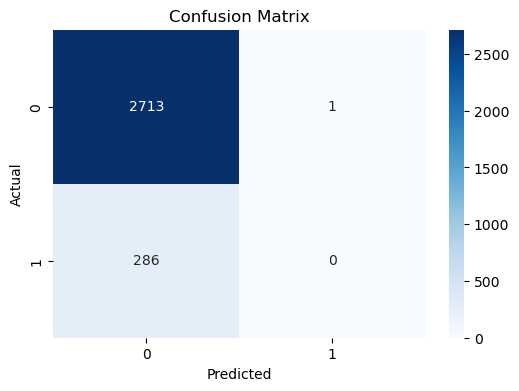

In [64]:
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Feature Importance Analysis
Feature importance identifies the most influential variables contributing to delivery delays.

This analysis helps understand which operational factors have the greatest impact on delivery performance.

In [65]:
#Extract Importance
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance

delivery_distance_km       0.241116
weather_severity_score     0.193646
traffic_level_score        0.180543
customer_rating            0.143148
delivery_partner_rating    0.131534
order_value                0.110012
dtype: float64

### Visualization of Important Features

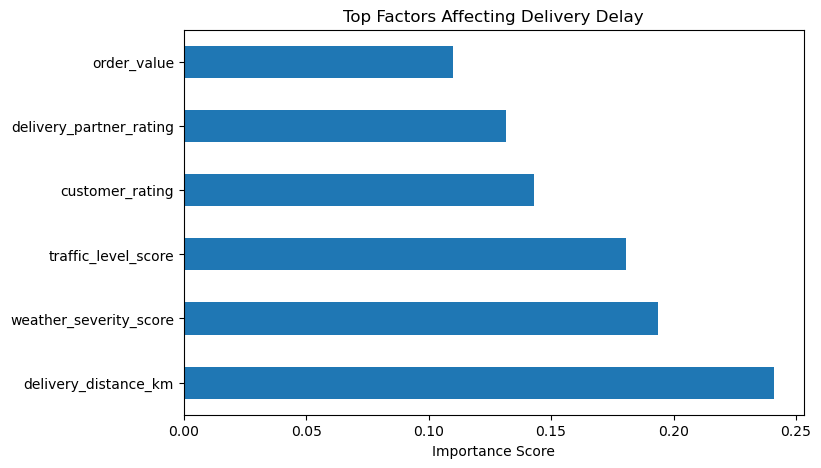

In [66]:

plt.figure(figsize=(8,5))
importance.head(10).plot(kind='barh')

plt.title('Top Factors Affecting Delivery Delay')
plt.xlabel('Importance Score')
plt.show()

### Feature Importance Insights:
The balanced Random Forest model identified delivery distance, weather severity, and traffic congestion as the strongest contributors to delivery delays.

Operational factors showed greater influence on delays compared to transactional variables such as order value, highlighting the importance of logistics optimization in improving delivery performance.

## Model Comparison 
### Logistic Regression Model
A Logistic Regression model is also developed to compare predictive performance with the Random Forest model.

In [67]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(class_weight='balanced')
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print(accuracy_score(y_test,lr_pred))

0.5106666666666667


### Model Insights:
The Random Forest classifier achieved substantially higher predictive accuracy compared to Logistic Regression after applying class balancing techniques.

This indicates that delivery delays are driven by complex interactions between operational variables such as traffic congestion, weather severity, and delivery distance.

In [68]:
from sklearn.metrics import classification_report

print("Random Forest Report")
print(classification_report(y_test, y_pred))

print("Logistic Regression Report")
print(classification_report(y_test, lr_pred))

Random Forest Report
              precision    recall  f1-score   support

       False       0.90      1.00      0.95      2714
        True       0.00      0.00      0.00       286

    accuracy                           0.90      3000
   macro avg       0.45      0.50      0.47      3000
weighted avg       0.82      0.90      0.86      3000

Logistic Regression Report
              precision    recall  f1-score   support

       False       0.91      0.51      0.65      2714
        True       0.10      0.49      0.16       286

    accuracy                           0.51      3000
   macro avg       0.50      0.50      0.41      3000
weighted avg       0.83      0.51      0.61      3000



### Model Comparison Insights:
The Random Forest classifier achieved high overall accuracy but struggled to identify delayed deliveries due to dataset imbalance.

Logistic Regression demonstrated lower overall accuracy but achieved better recall for delayed deliveries, making it more effective for identifying high-risk delayed orders.

This highlights the importance of evaluating machine learning models beyond accuracy when working with imbalanced datasets.

# Conclusion

This project successfully combined exploratory data analysis and machine learning techniques to analyze food delivery operations and predict delivery delays.

The analysis identified delivery distance, weather severity, and traffic congestion as major contributors to delivery delays.

Machine learning models demonstrated the importance of handling imbalanced datasets and evaluating models using metrics beyond overall accuracy.

The project highlights how predictive analytics can support operational optimization, improve delivery efficiency, and enhance customer satisfaction in food delivery platforms.